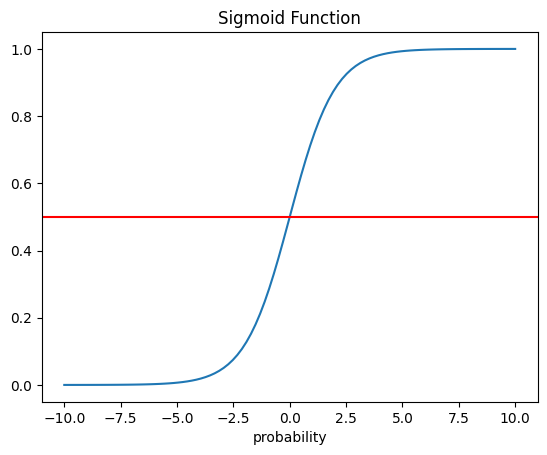

In [6]:
import numpy as np
import  matplotlib.pyplot as plt

z=np.linspace(-10,10,100)
sigmoid= 1/(1+np.exp(-z))

sigmoid.shape

plt.plot(z,sigmoid)
plt.axhline(y=0.5,color="r")
plt.title("Sigmoid Function")
plt.xlabel("probability")
plt.show()

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score


df=sns.load_dataset("titanic")

print(df.head())
print(df.isnull().sum())

   survived  pclass     sex   age  ...  deck  embark_town  alive  alone
0         0       3    male  22.0  ...   NaN  Southampton     no  False
1         1       1  female  38.0  ...     C    Cherbourg    yes  False
2         1       3  female  26.0  ...   NaN  Southampton    yes   True
3         1       1  female  35.0  ...     C  Southampton    yes  False
4         0       3    male  35.0  ...   NaN  Southampton     no   True

[5 rows x 15 columns]
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [14]:
df=df[["survived","pclass","sex","age","fare"]]
df["age"]=df["age"].fillna(df["age"].median())

df["sex"]=df["sex"].map({"male":0,
                         "female":1})
print(df.isnull().sum())
print(df.head())

survived    0
pclass      0
sex         0
age         0
fare        0
dtype: int64
   survived  pclass  sex   age     fare
0         0       3    0  22.0   7.2500
1         1       1    1  38.0  71.2833
2         1       3    1  26.0   7.9250
3         1       1    1  35.0  53.1000
4         0       3    0  35.0   8.0500


In [15]:
X=df[["pclass","sex","age","fare"]]
y=df["survived"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=LogisticRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)


print("Accuracy= ", accuracy_score(y_test,y_pred))

print(classification_report(y_test,y_pred))

Accuracy=  0.8044692737430168
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



Confusion Matrix=
         Predicted 1  predicted 0
actual 1    TP           FN
actual 0    FP           TN


Precision= TP/TP+FP

Recall= TP/TP+FN

F1 Score= 2*((Precision into Recall)/(Precision + Recall))

Support= Number of actual datasets in our dataset

Accuracy= TP+TN/TP+TN+FP+FN


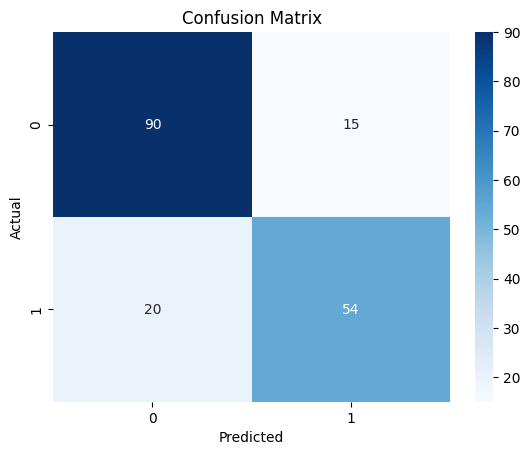

In [16]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In detail version of Logistic Regression without sklearn

In [18]:
import numpy as np

def sigmoid(z):
  z=1/(1+np.exp(-z))
  return z


def LogisticReg(X,y,learning_rate=0.01,iterations=1000):
  m,n=X.shape
  theta=np.zeros(n)

  for i in range(iterations):
    z=X@theta
    predictions=sigmoid(z)

    gradient=(1/m)*X.T@(predictions-y)
    theta=theta-learning_rate*gradient

  return theta

from sklearn.model_selection import train_test_split
import seaborn as sns
import pandas as pd

X=np.c_[np.ones(X.shape[0]),X]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

theta=LogisticReg(X_train,y_train)

def predict(X,theta):
  return (sigmoid(X@theta)>=0.5).astype(int)

y_pred=predict(X_test,theta)

accuracy=np.mean(y_pred==y_test)
print(accuracy)

0.6145251396648045


Great answers, all correct. Quick feedback:
Why not linear regression ✅ — Perfect. You also could add that linear regression can predict values above 1 or below 0 which makes no sense for probability.
Accuracy ✅ — Exactly right. You even remembered the formula which most beginners don't bother with.
Precision vs Recall ✅ — Correct direction. Just to sharpen the explanation:
High precision means when your model predicts survived, it's usually right. Few false positives.
High recall means your model catches most actual survivors. Few false negatives.
For Titanic specifically — higher precision makes sense because the dataset has more deaths than survivors. The model becomes conservative about predicting survival, so when it does predict survived it's usually correct.